In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
import pickle
%matplotlib inline

In [3]:
df = pd.read_excel("data\crop_recommendation_better.xlsx")
df.head()

,N,P,K,pH,Temp(°C),Humidity(%),Moisture(%),Rainfall(mm),Crop
0,146.0,44.0,26,6.2,31,76.0,81,124,Aman Rice
1,229.0,35.0,31,6.1,22,73.3,72,137,Aman Rice
2,281.0,26.0,35,6.0,32,79.5,86,124,Aman Rice
3,161.0,23.0,42,6.2,36,71.8,86,145,Aman Rice
4,155.0,45.0,34,6.3,22,73.0,71,144,Aman Rice


In [4]:
df["Crop"].unique()

array(['Aman Rice', 'Aush Rice', 'Bean', 'Boro Rice', 'Calabash',
       'Cauliflower', 'Colocasia leaves', 'Corn', 'Eggplant', 'Jute',
       'Leafy Veg', 'Oil crop', 'Onion', 'Papaya', 'Peanut', 'Pineapple',
       'Pointed Gourd', 'Potato', 'Pulse', 'Pumpkin', 'Tomato', 'Wheat'],
      dtype=object)

In [5]:
df.describe()

,N,P,K,pH,Temp(°C),Humidity(%),Moisture(%),Rainfall(mm)
count,3300.000000,3300.000000,3300.000000,3300.000000,3300.00000,3300.000000,3300.000000,3300.000000
mean,223.727909,57.865758,81.821818,5.854636,25.86000,70.890485,65.566667,100.575455
std,70.689646,23.486225,66.377865,0.734418,5.73982,6.918953,19.980578,40.117183
min,55.000000,14.000000,9.000000,3.300000,13.00000,55.000000,12.000000,40.000000
25%,160.000000,43.000000,39.000000,5.600000,22.00000,66.200000,60.000000,67.750000
50%,210.000000,49.000000,61.000000,6.100000,26.00000,71.300000,70.000000,95.000000
75%,275.000000,78.000000,93.000000,6.300000,30.00000,75.600000,79.000000,127.000000
max,399.000000,444.000000,450.000000,6.700000,40.00000,85.900000,95.000000,250.000000


In [6]:
df.isnull().sum()

N               0
P               0
K               0
pH              0
Temp(°C)        0
Humidity(%)     0
Moisture(%)     0
Rainfall(mm)    0
Crop            0
dtype: int64

In [7]:
df.duplicated().sum()

0

# Future improvements
In additional data , each column would be normalized and the rank according to the importance of each feature and the multiplied by some factor which is directly proportional to their importance.

Additional_data would contain columns such as :
1. Water Requirement (High , Mid , Low)
3. Soil Type
4. Crop Rotation Rules
5. Market Price
6. Rabi/Kharif (Season)
7. Fertilizer req
8. Labor req
9. Pesticides req
10. Probability using the previous part of the engine

# EDA

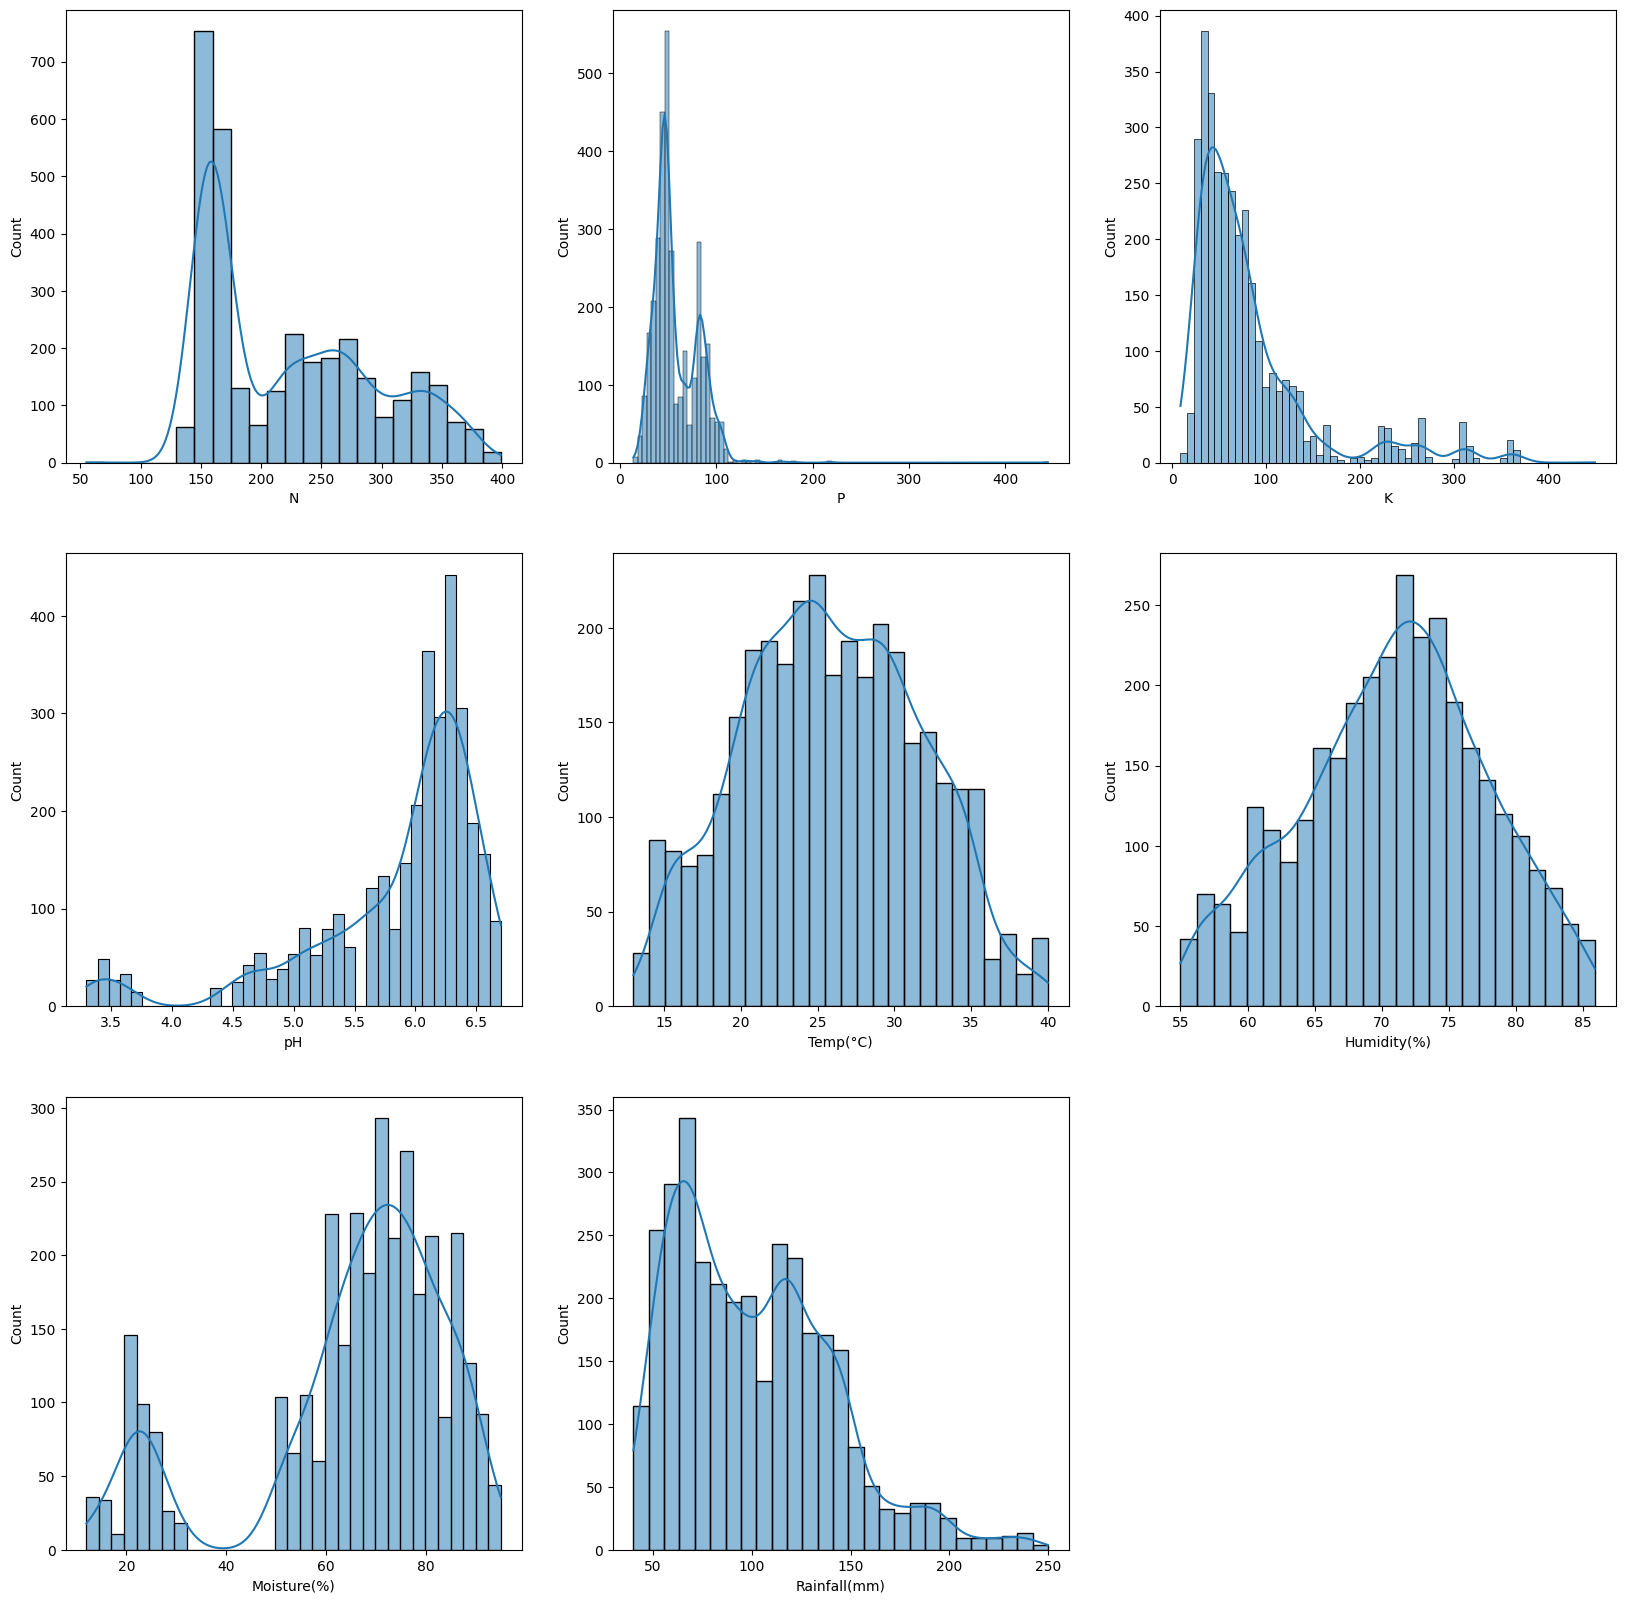

In [9]:
soil_prop_columns = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)','Rainfall(mm)']
def prop_distribution(df=df):
    i=1
    plt.figure(figsize=(20,20))
    for prop in soil_prop_columns:
        plt.subplot(3,3,i)
        sns.histplot(df[prop],kde=True)
        i+=1
    plt.show()

prop_distribution()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_23612\2271070662.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True)


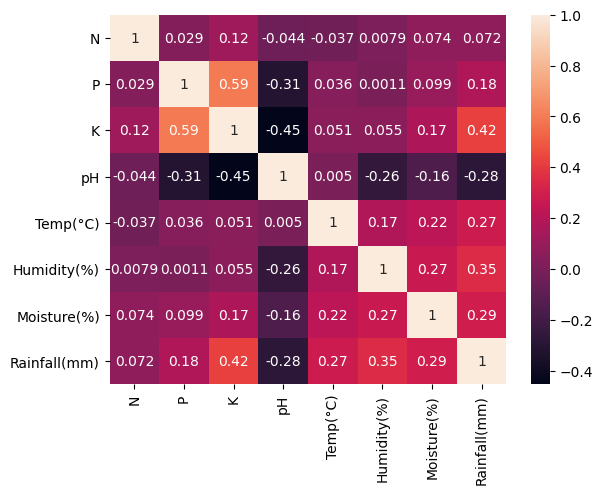

In [10]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [11]:
crops = df['Crop'].unique()
crops

array(['Aman Rice', 'Aush Rice', 'Bean', 'Boro Rice', 'Calabash',
       'Cauliflower', 'Colocasia leaves', 'Corn', 'Eggplant', 'Jute',
       'Leafy Veg', 'Oil crop', 'Onion', 'Papaya', 'Peanut', 'Pineapple',
       'Pointed Gourd', 'Potato', 'Pulse', 'Pumpkin', 'Tomato', 'Wheat'],
      dtype=object)

# SKEWNESS Handling

In [12]:
print(f"prop\tSkew\tlog1p\tsq")
for prop in soil_prop_columns:
    print(f"{prop}\t{df[prop].skew():.2f}\t{np.log1p(df[prop]).skew():.2f}\t{np.square(df[prop]).skew():.2f}")

prop	Skew	log1p	sq
N	0.59	0.28	0.92
P	2.25	0.13	22.50
K	2.25	0.62	3.62
pH	-1.71	-2.08	-1.32
Temp(°C)	0.04	-0.42	0.49
Humidity(%)	-0.15	-0.36	0.06
Moisture(%)	-1.17	-1.83	-0.49
Rainfall(mm)	0.80	0.01	1.82


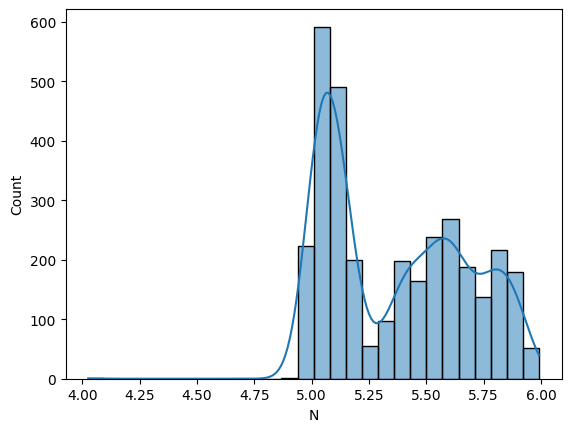

In [13]:
sns.histplot(x=np.log1p(df["N"]),kde=True)
plt.show()

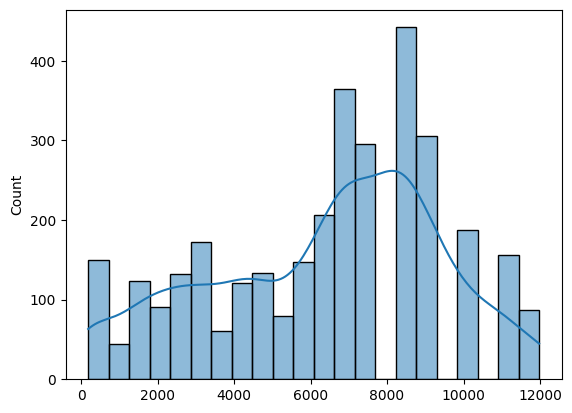

5.8671510730217555


In [14]:
from scipy import stats
transformed_data, best_lambda = stats.boxcox(df["pH"])
sns.histplot(x=transformed_data,kde=True)
plt.show()
print(best_lambda)

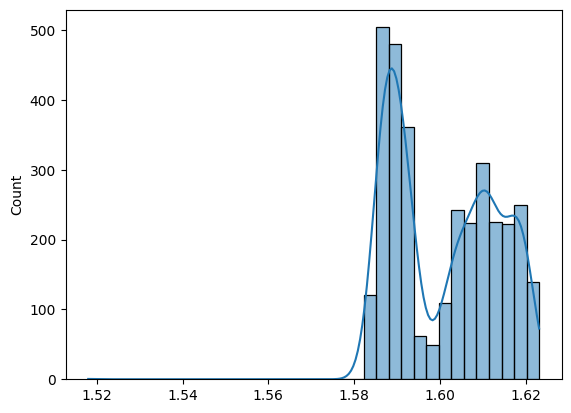

-0.5990396728747479


In [15]:
from scipy import stats
transformed_data, best_lambda = stats.boxcox(df["N"])
sns.histplot(x=transformed_data,kde=True)
plt.show()
print(best_lambda)

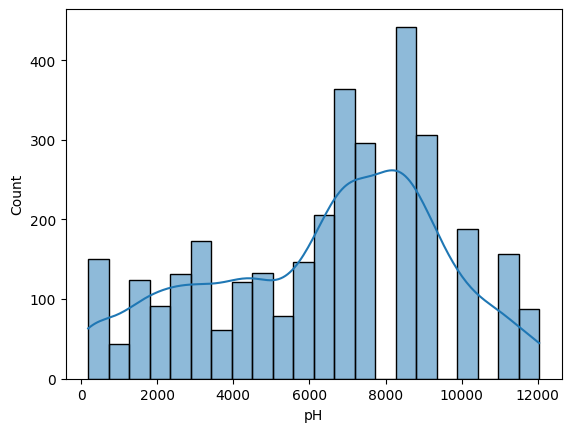

In [16]:
sns.histplot(x=df["pH"].map(lambda x : (x**5.87-1)/5.87),kde=True)
plt.show()

# Final verdicts 
## p,K,Rainfall(mm)-->log1p
## pH --> boxcox , lambda = 5.87

In [17]:
def plot_helper(feature,df=df):
    i = 1
    try:
        plt.figure(figsize=(30,30))
        for crop in crops:
            plt.subplot(4,6,i)
            sns.histplot(data=df[df["Crop"] == crop],x=feature,kde=True)
            plt.title(f"{feature},{crop}")
            i+=1
        plt.show()
    except Exception:
        print(f"Something went wrong. Check if feature name has been correctly given!")

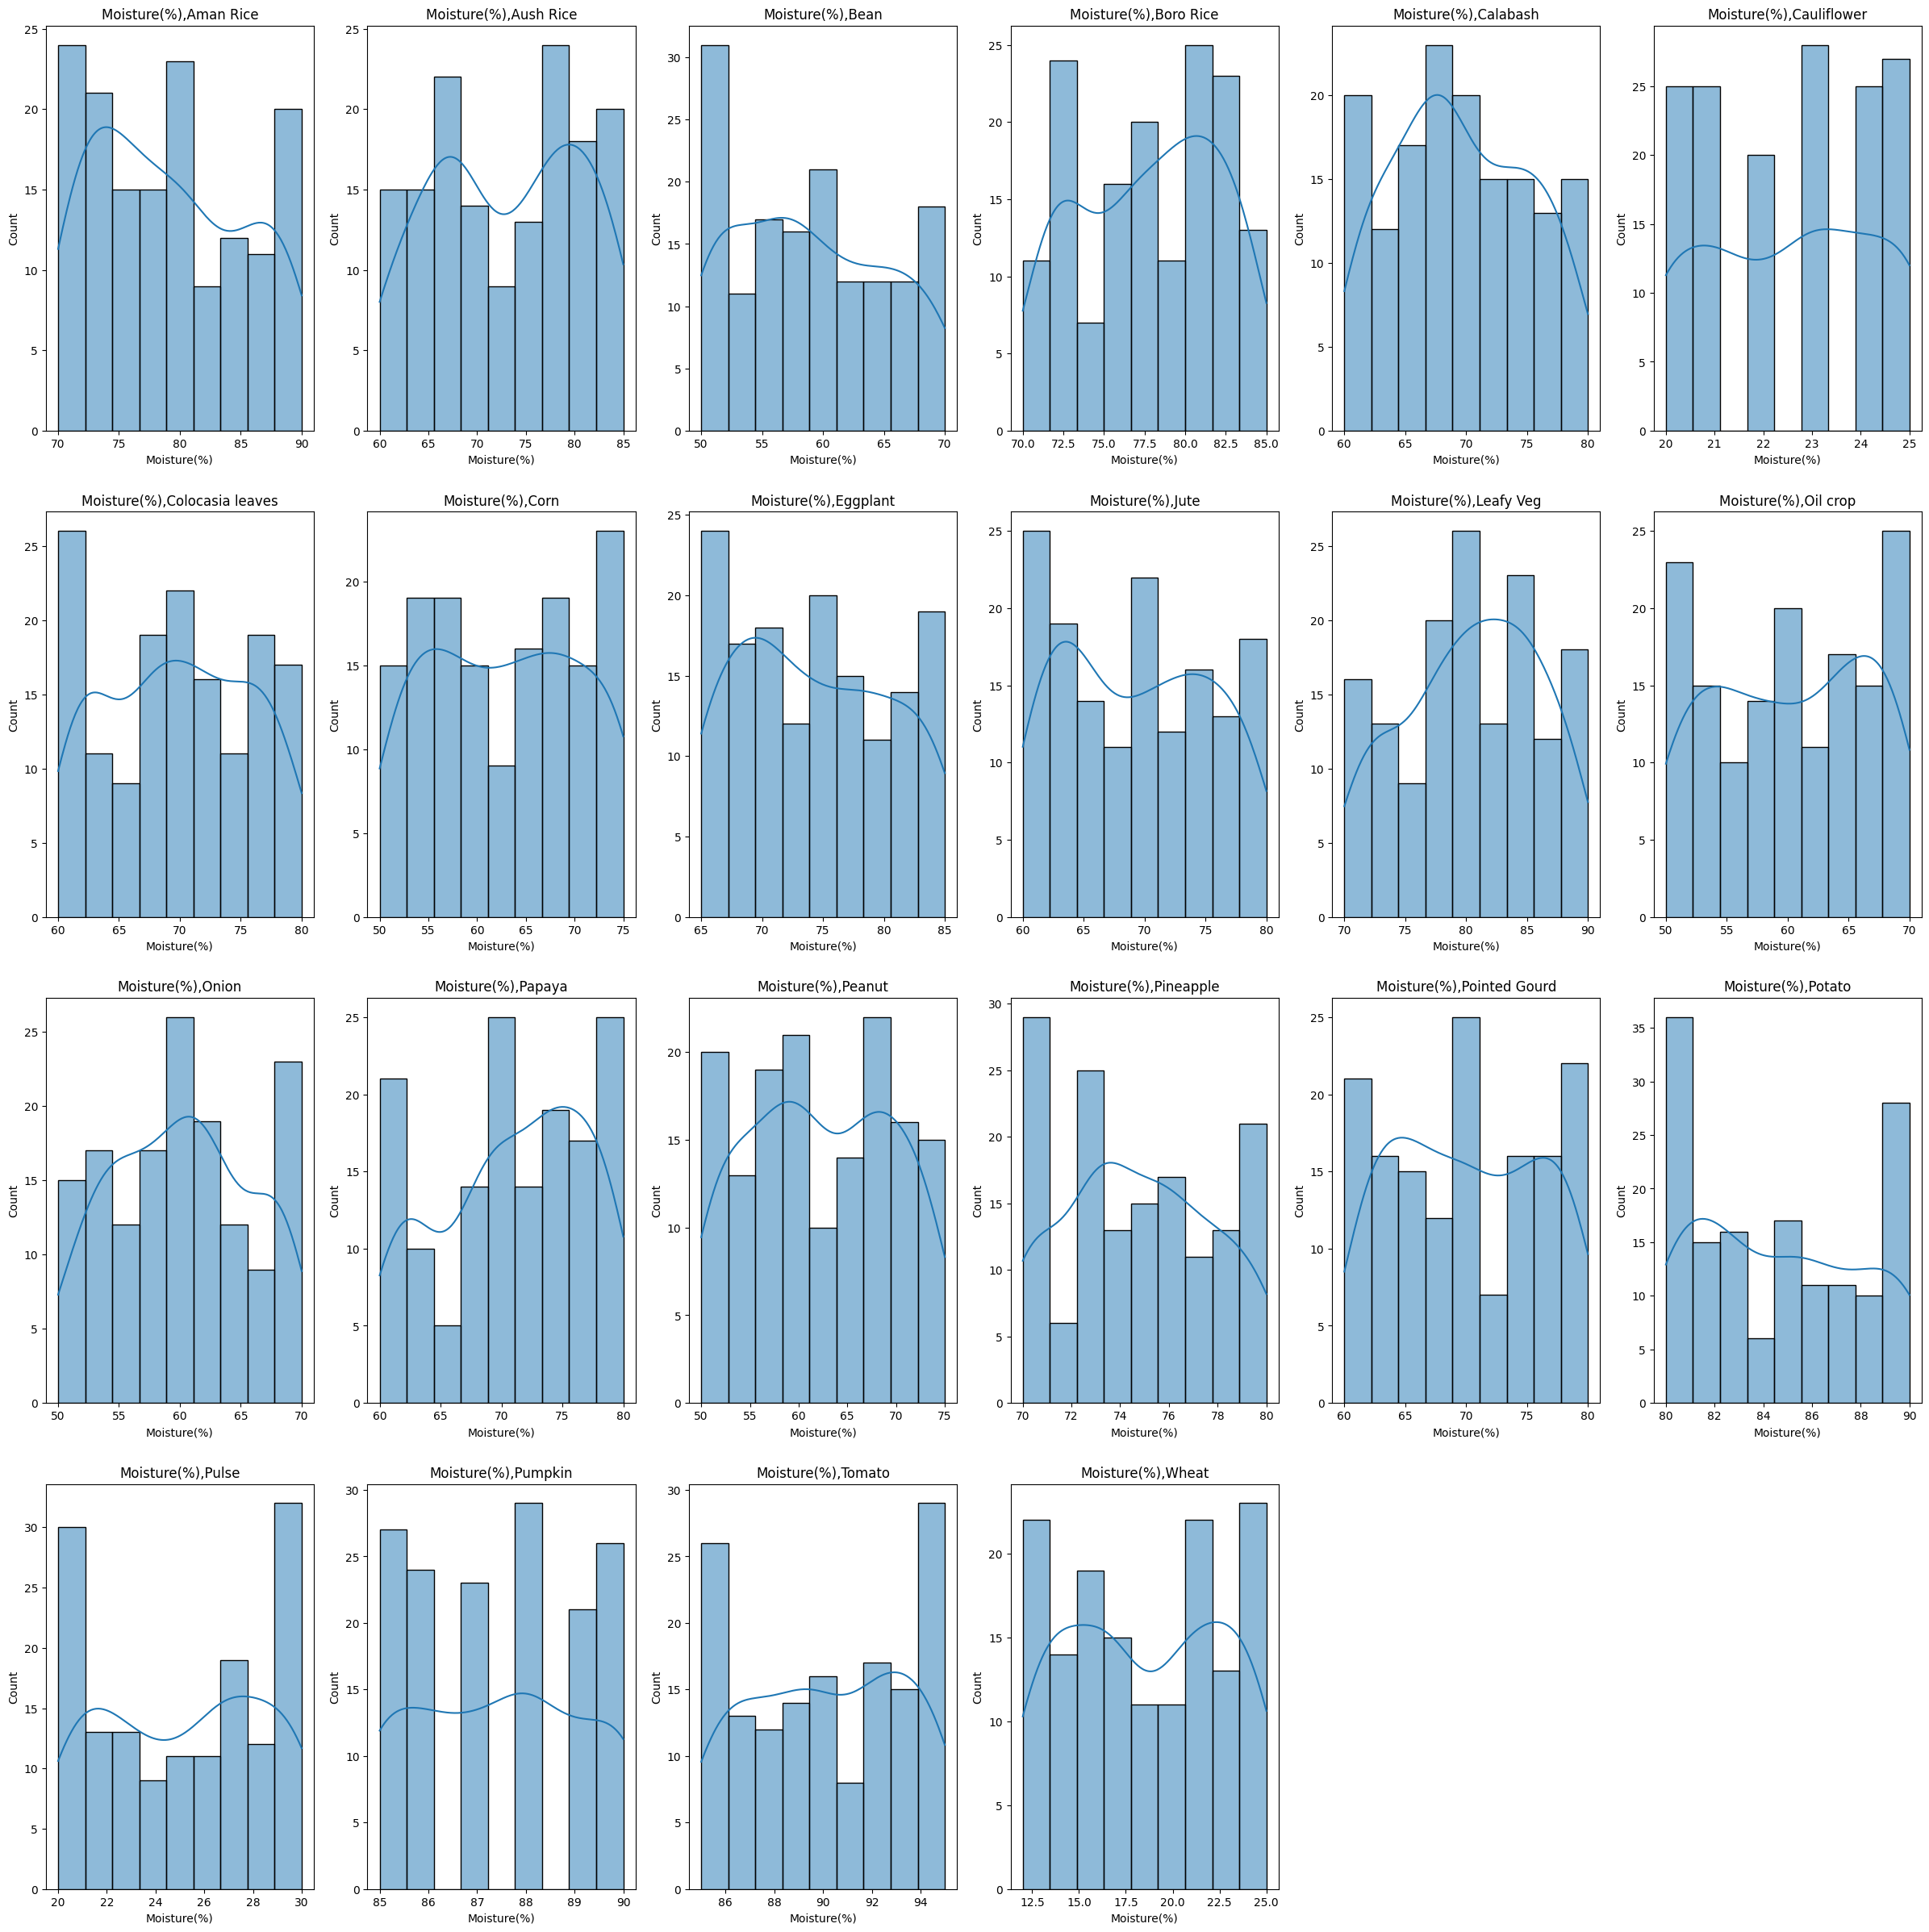

In [18]:
plot_helper("Moisture(%)")

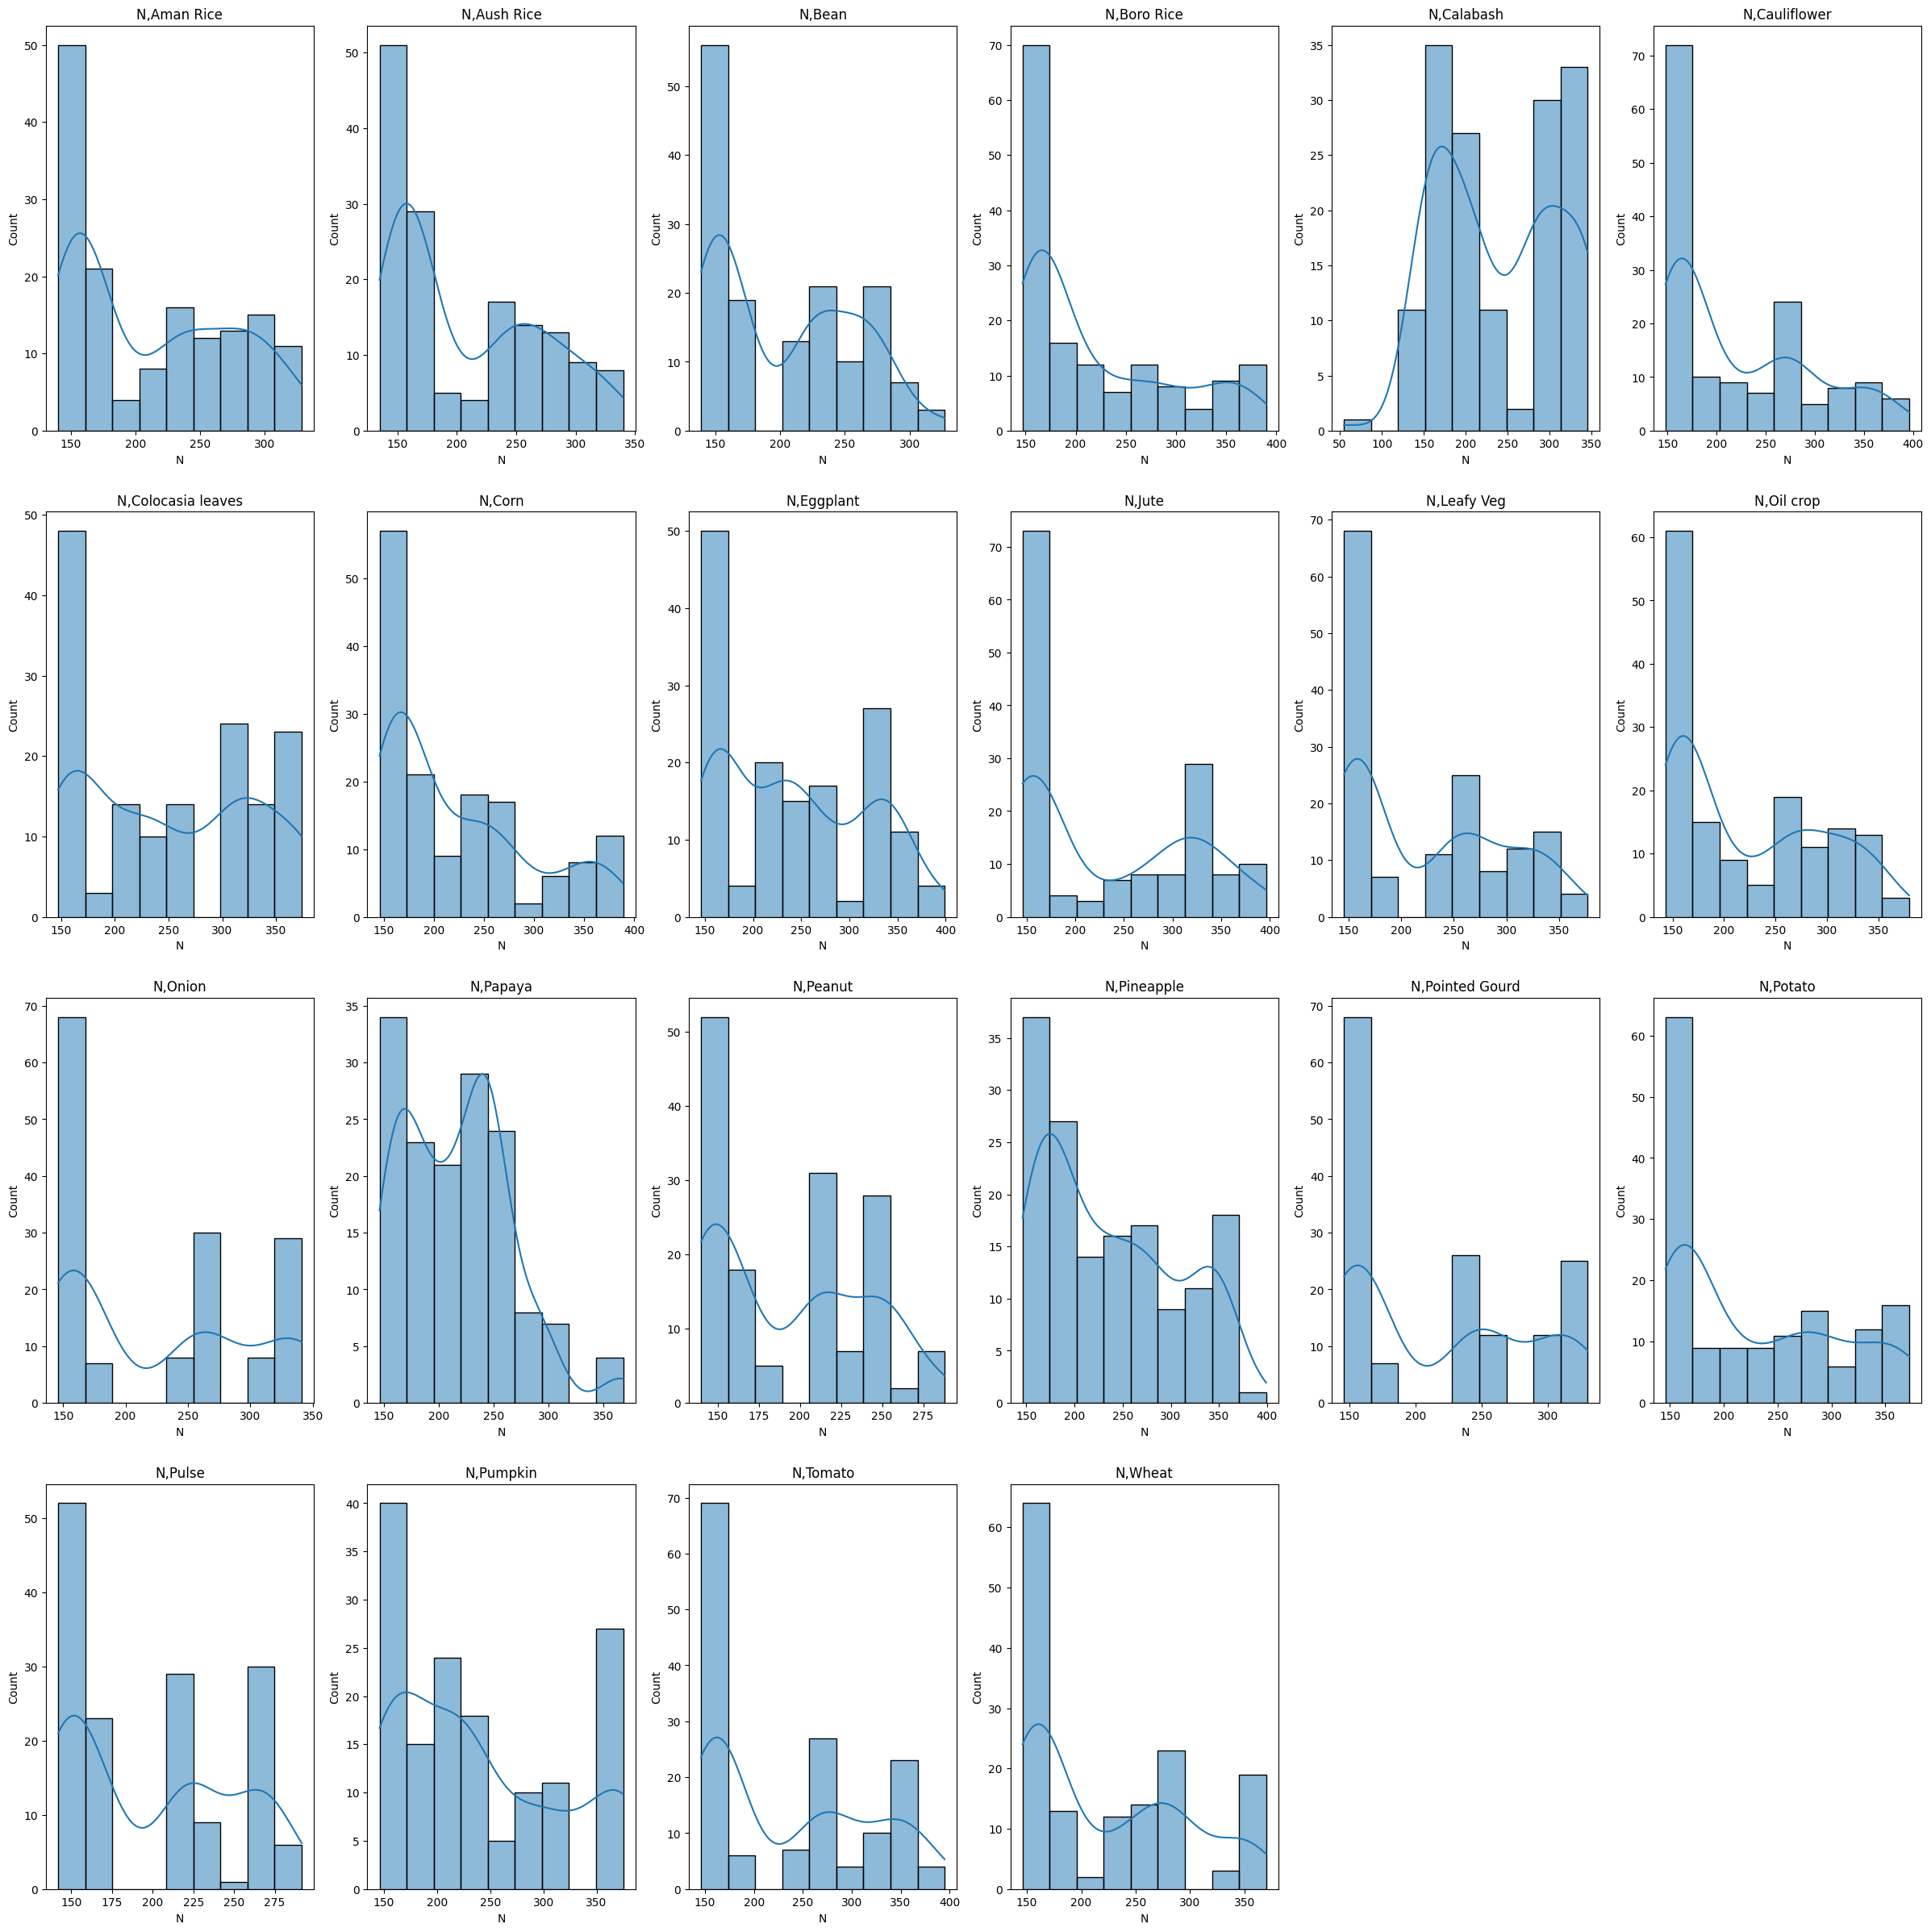

In [19]:
plot_helper("N")

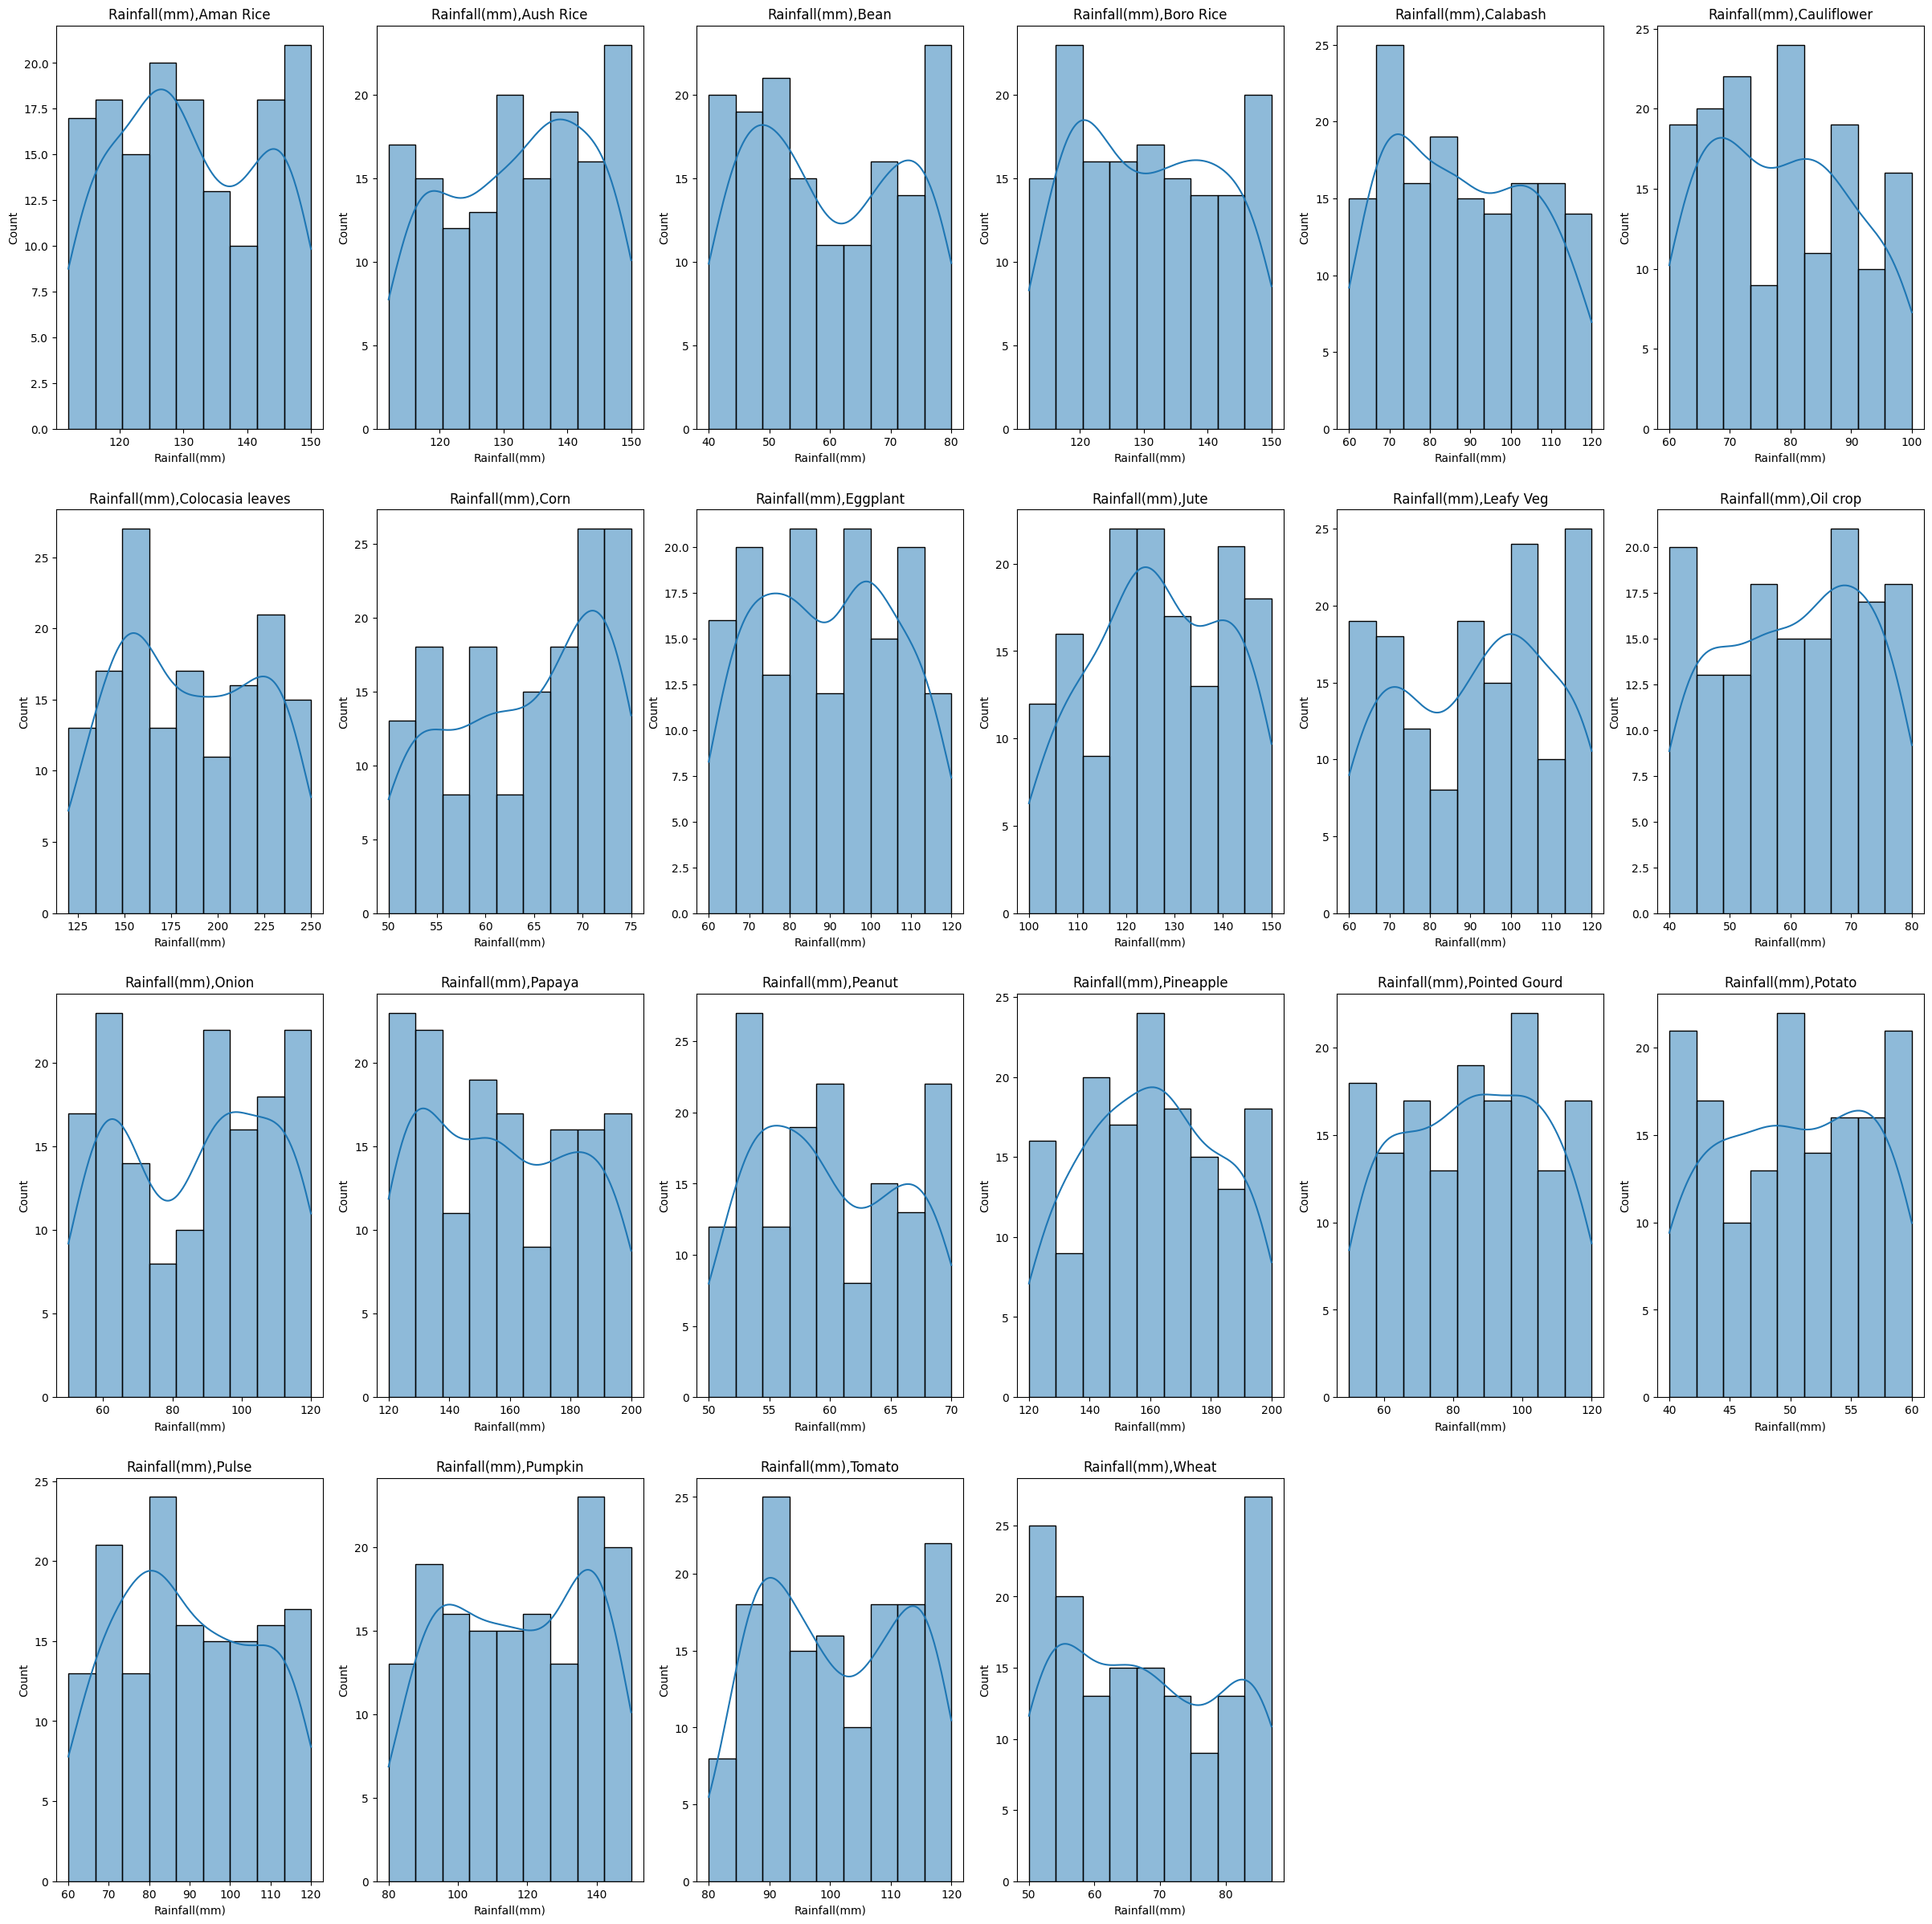

In [20]:
plot_helper("Rainfall(mm)")

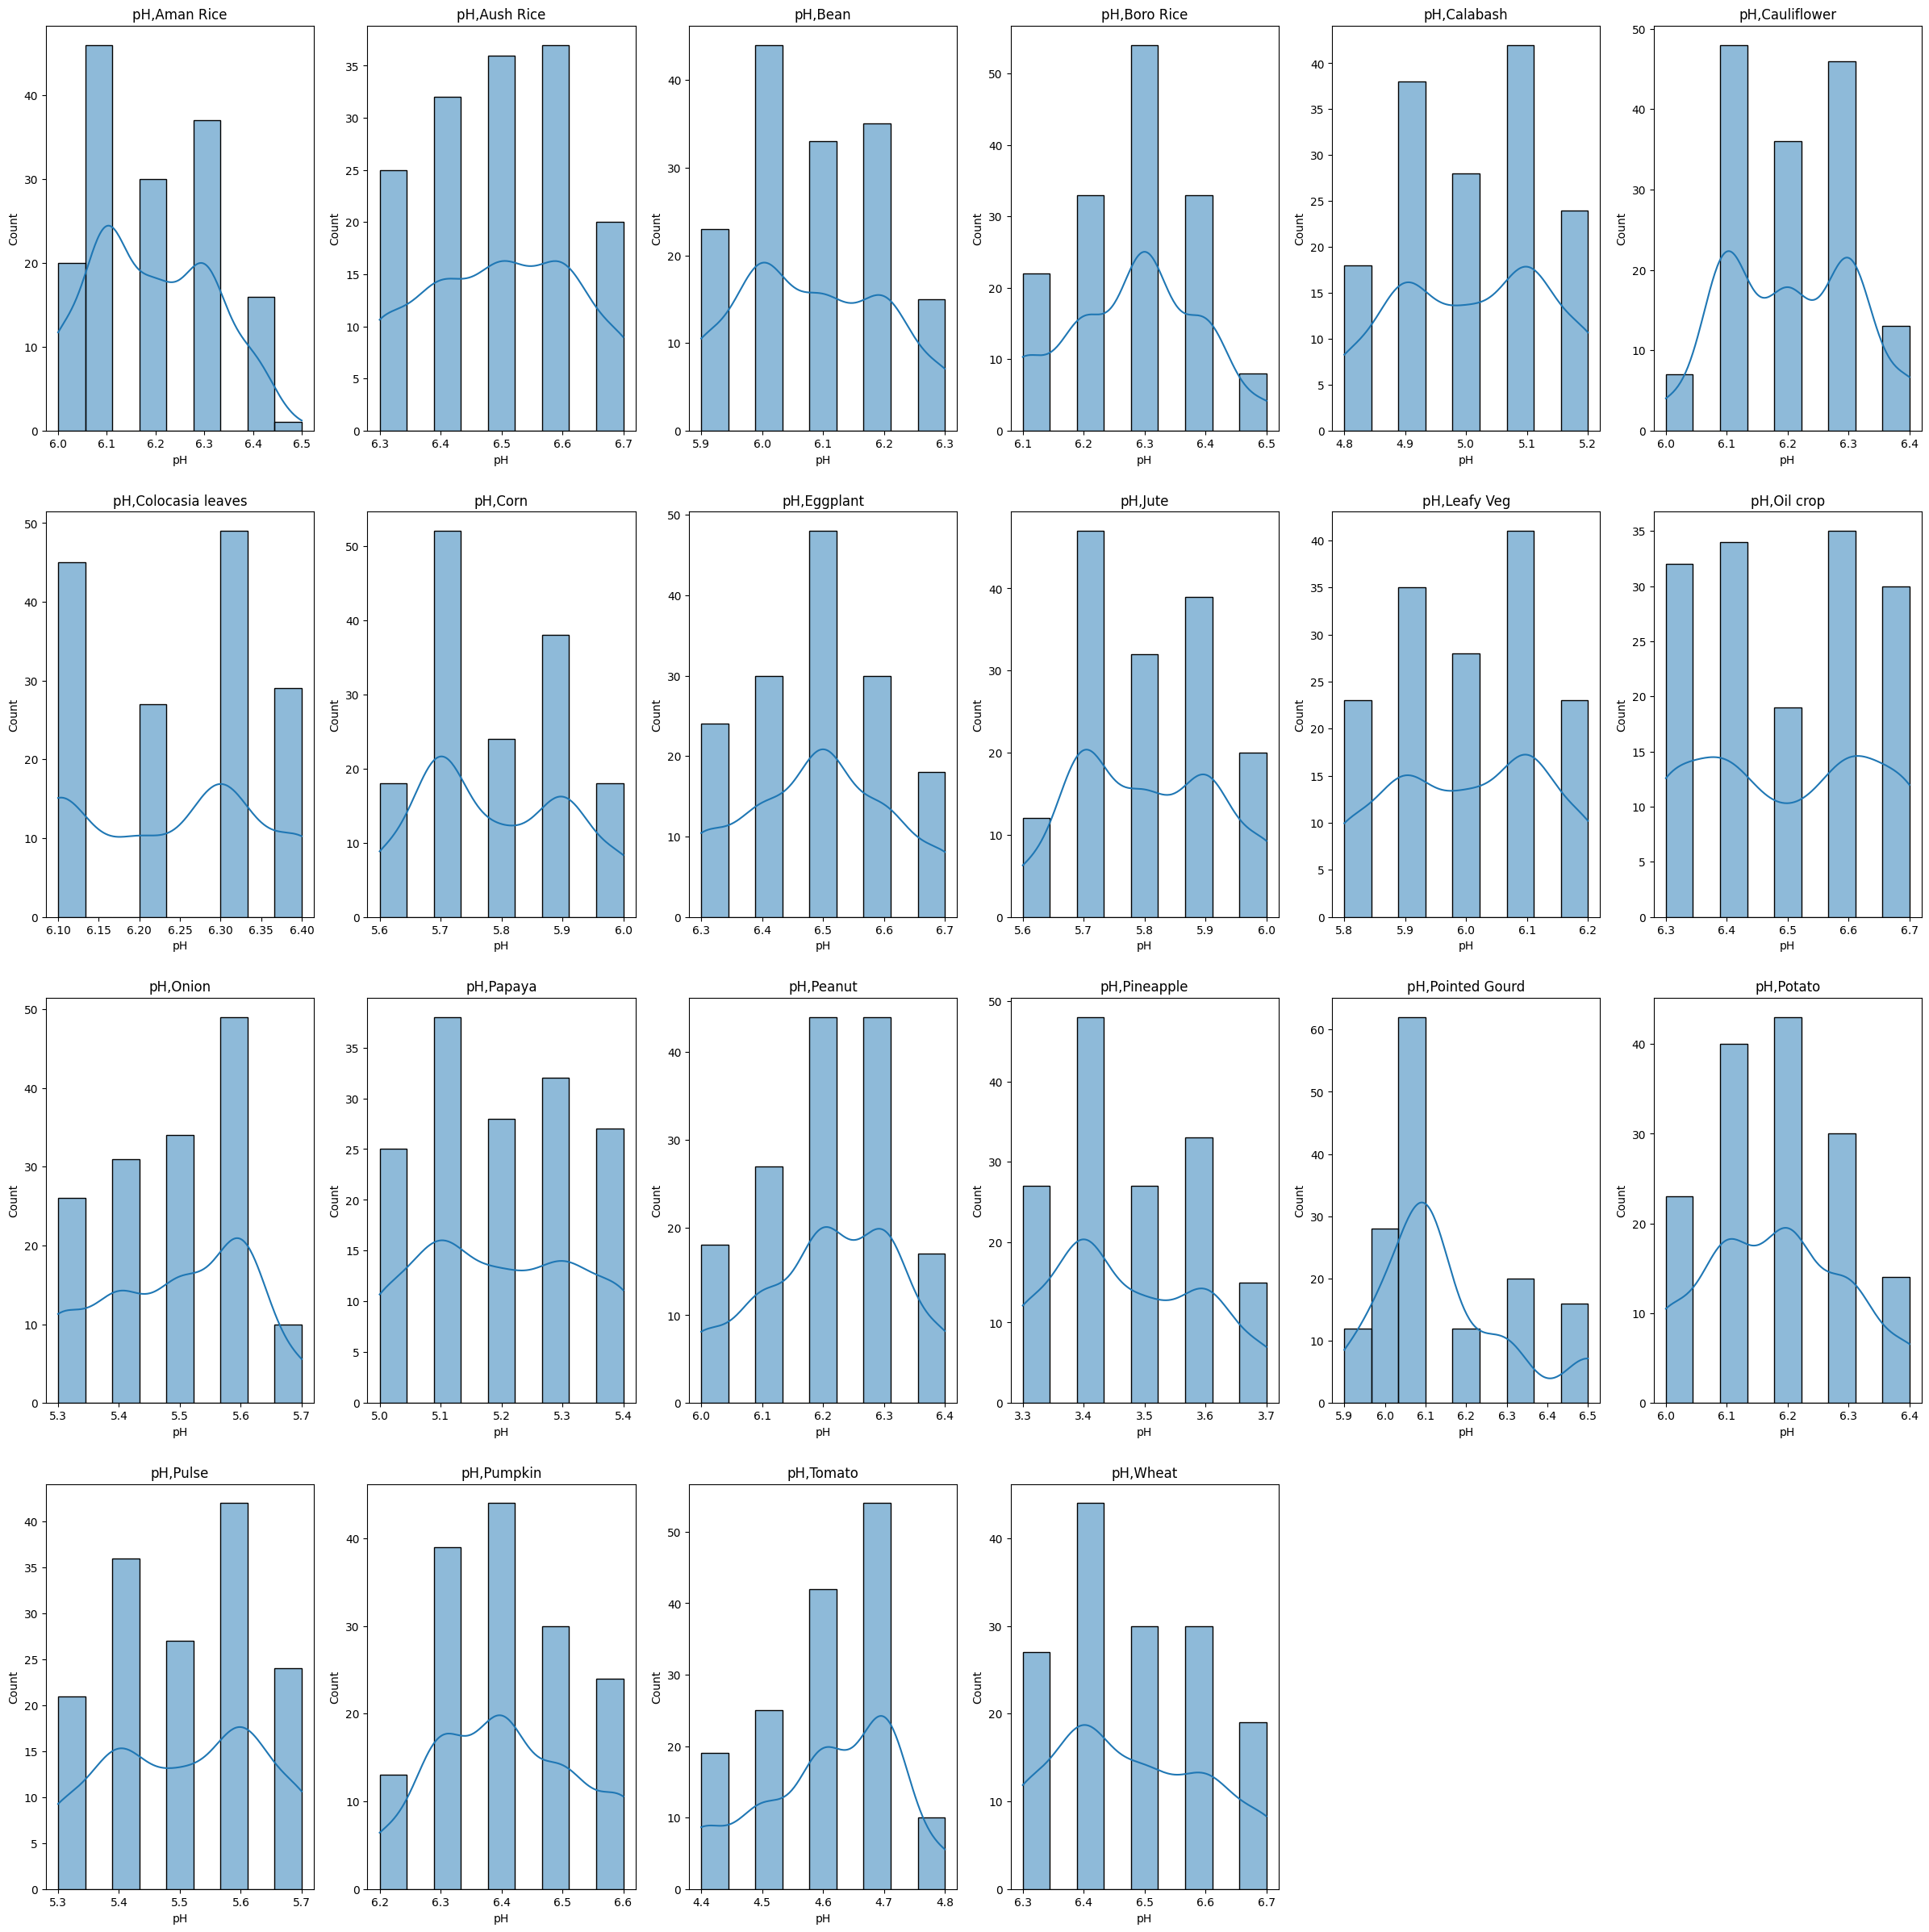

In [21]:
plot_helper("pH")

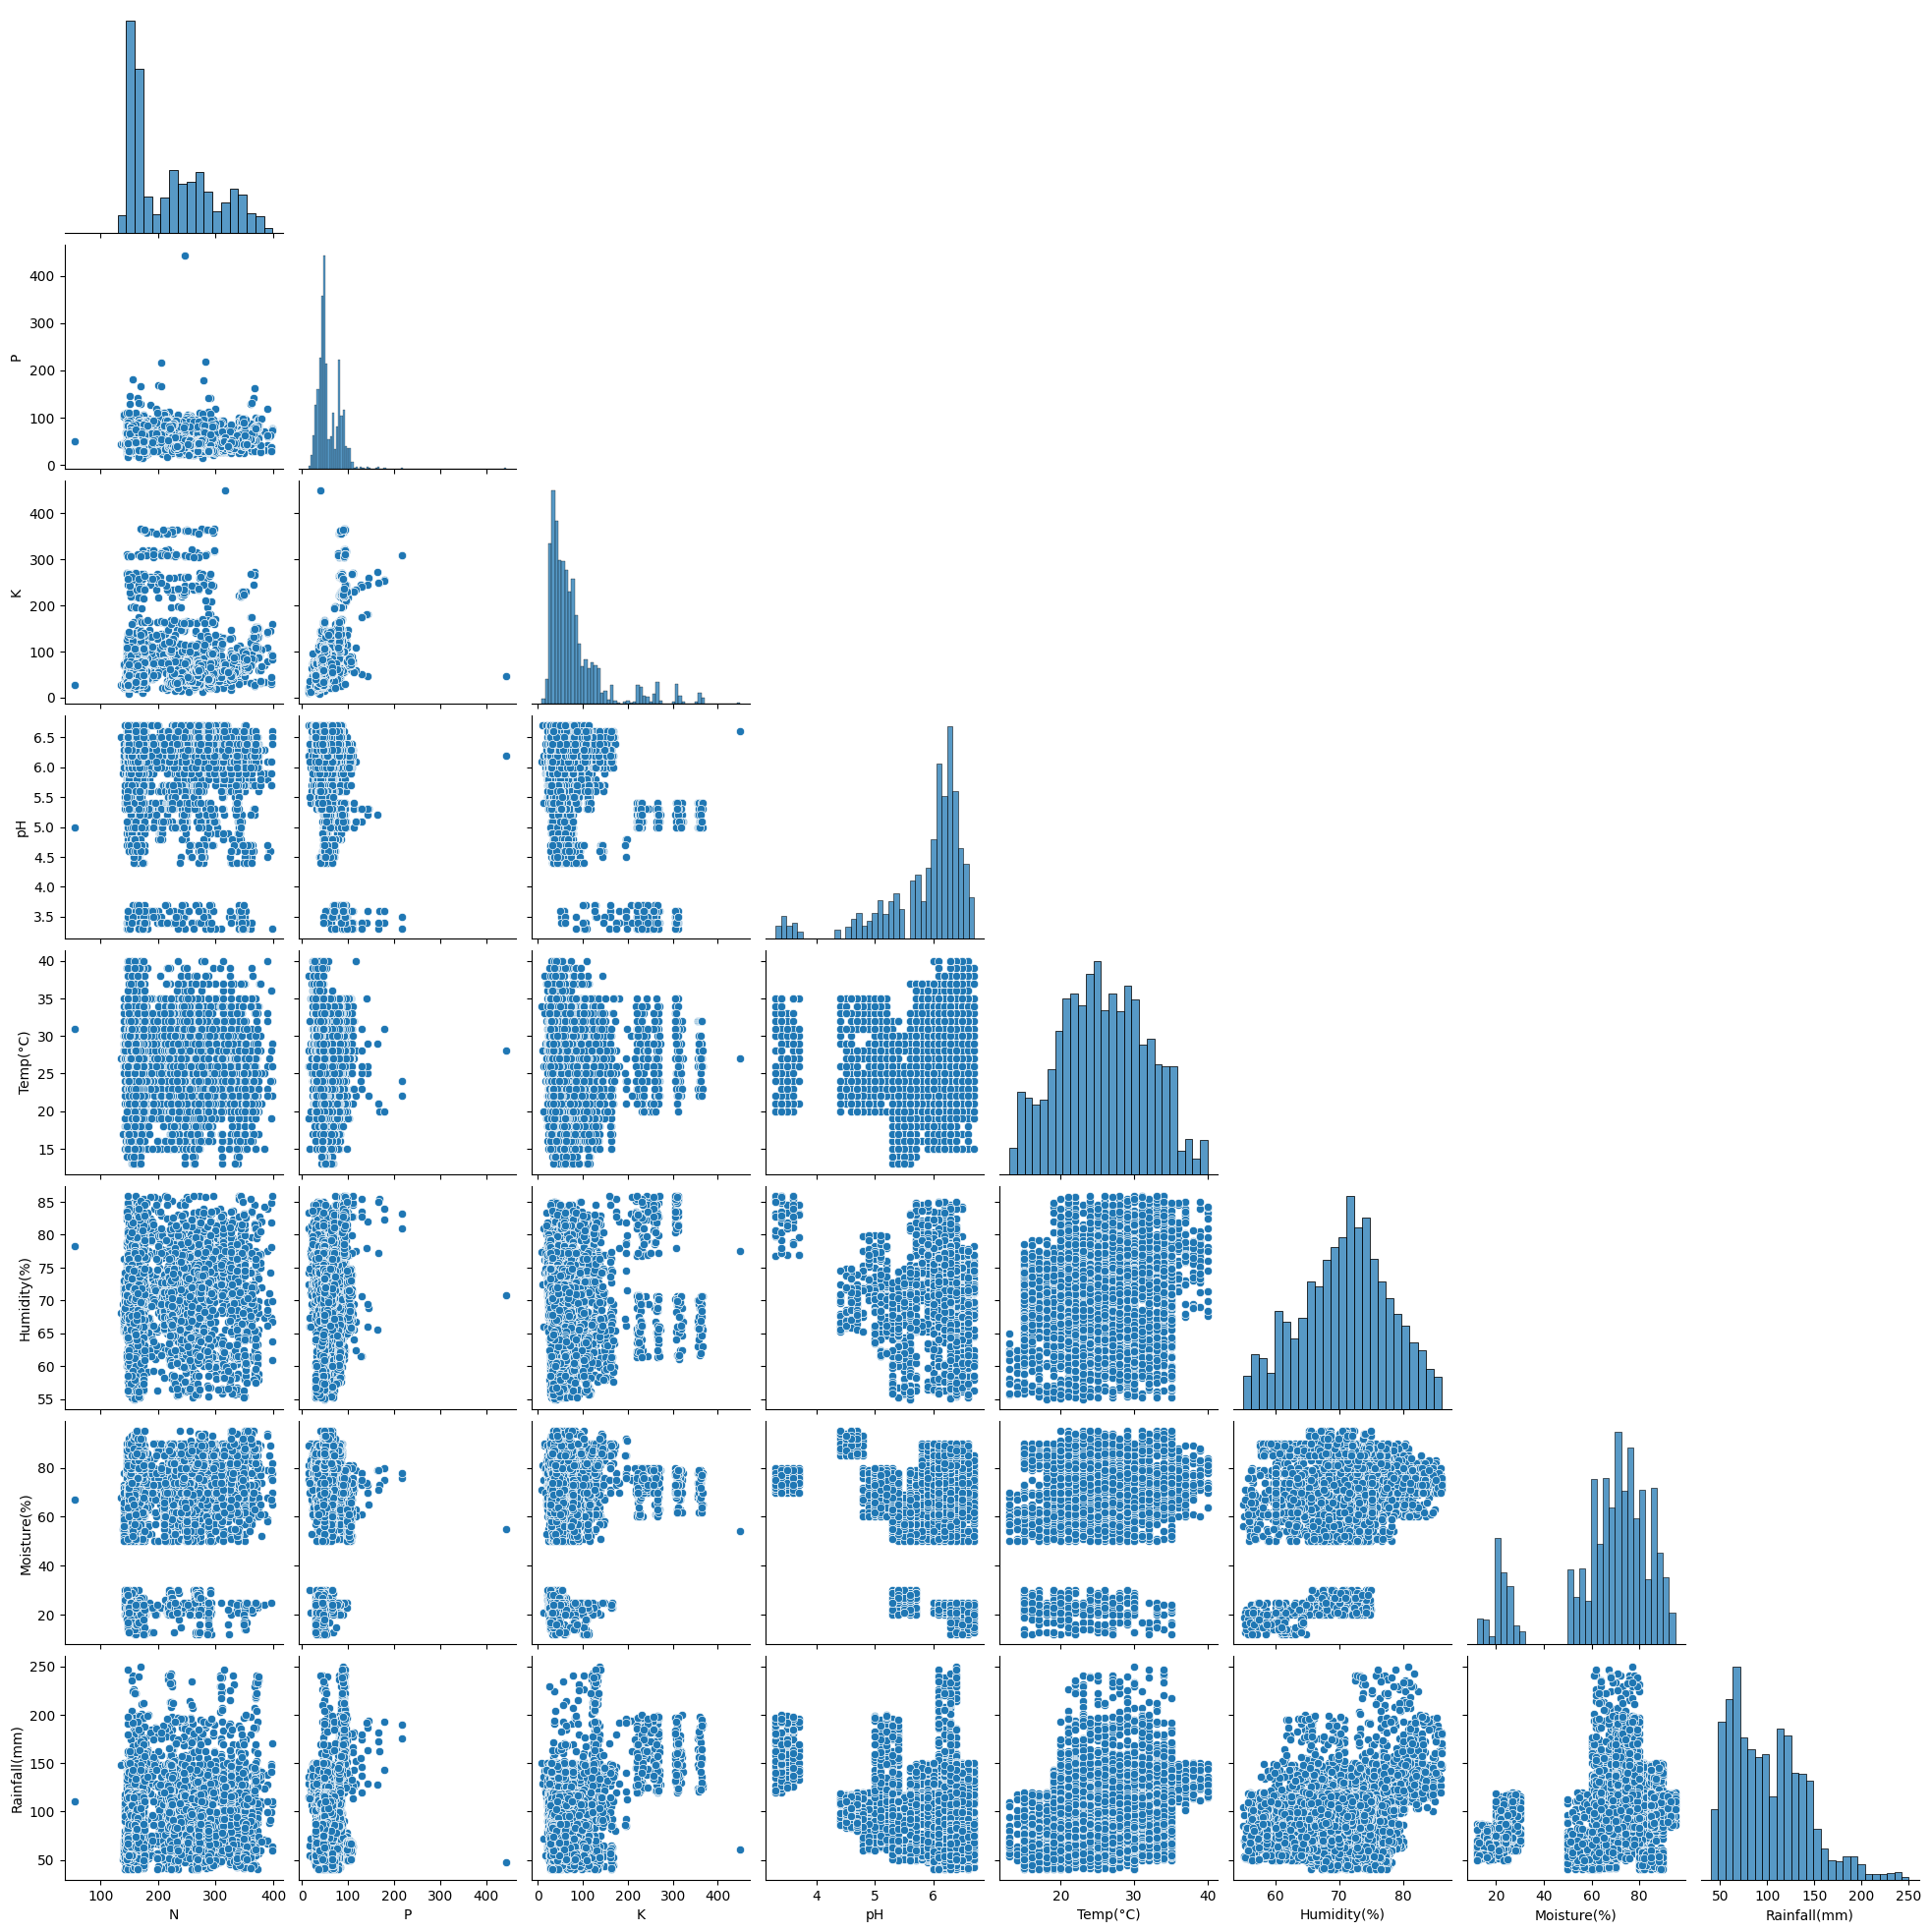

In [22]:
sns.pairplot(data=df.drop(columns="Crop"),corner=True)
plt.show()

# Feature Preprocessing

In [23]:
df["transformed_P"] = np.log1p(df["P"])
df["transformed_K"] = np.log1p(df["K"])
df["transformed_rainfall"] = np.log1p(df["Rainfall(mm)"])
df["transformed_pH"] = df["pH"].map(lambda x : (x**5.87-1)/5.87)
df.drop(columns=["P","K","Rainfall(mm)","pH"],inplace=True)

In [24]:
df.head()

,N,Temp(°C),Humidity(%),Moisture(%),Crop,transformed_P,transformed_K,transformed_rainfall,transformed_pH
0,146.0,31,76.0,81,Aman Rice,3.806662,3.295837,4.828314,7632.932526
1,229.0,22,73.3,72,Aman Rice,3.583519,3.465736,4.927254,6938.049063
2,281.0,32,79.5,86,Aman Rice,3.295837,3.583519,4.828314,6296.482322
3,161.0,36,71.8,86,Aman Rice,3.178054,3.761200,4.983607,7632.932526
4,155.0,22,73.0,71,Aman Rice,3.828641,3.555348,4.976734,8384.595200


In [25]:
X = df.drop(columns="Crop")
y = df["Crop"]
crop_le = LabelEncoder()
y = crop_le.fit_transform(y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [ ]:
filename = 'crop_label_encoder.pkl'
with open(filename, 'wb') as file:
    pickle.dump(crop_le, file)
with open(filename, 'rb') as file:
    loaded_encoder = pickle.load(file)
print(loaded_encoder.inverse_transform(list(range(22))))

['Aman Rice' 'Aush Rice' 'Bean' 'Boro Rice' 'Calabash' 'Cauliflower'
 'Colocasia leaves' 'Corn' 'Eggplant' 'Jute' 'Leafy Veg' 'Oil crop'
 'Onion' 'Papaya' 'Peanut' 'Pineapple' 'Pointed Gourd' 'Potato' 'Pulse'
 'Pumpkin' 'Tomato' 'Wheat']


In [27]:
print(crop_le.inverse_transform(list(range(22))))

['Aman Rice' 'Aush Rice' 'Bean' 'Boro Rice' 'Calabash' 'Cauliflower'
 'Colocasia leaves' 'Corn' 'Eggplant' 'Jute' 'Leafy Veg' 'Oil crop'
 'Onion' 'Papaya' 'Peanut' 'Pineapple' 'Pointed Gourd' 'Potato' 'Pulse'
 'Pumpkin' 'Tomato' 'Wheat']


In [28]:
col_scaler={}
col_name_mapper = {
    "transformed_P" : "P",
    "transformed_K" : "K",
    "transformed_pH" : "pH",
    "transformed_rainfall" : "rainfall",
    "Temp(°C)" : "temperature",
    "Humidity(%)" : "humidity",
    "Moisture(%)" : "moisture"
}
for col in X.columns :
    soil_prop_name = col_name_mapper.get(col,col)
    scaler = StandardScaler()
    X_train[col] = scaler.fit_transform(X_train[[col]])
    X_test[col] = scaler.transform(X_test[[col]])
    col_scaler[soil_prop_name]=scaler

In [29]:
col_scaler

{'N': StandardScaler(),
 'temperature': StandardScaler(),
 'humidity': StandardScaler(),
 'moisture': StandardScaler(),
 'P': StandardScaler(),
 'K': StandardScaler(),
 'rainfall': StandardScaler(),
 'pH': StandardScaler()}

In [30]:
filename = 'column_scalers.pkl'
with open(filename, 'wb') as file:
    pickle.dump(col_scaler, file)

In [31]:
X_train

,N,Temp(°C),Humidity(%),Moisture(%),transformed_P,transformed_K,transformed_rainfall,transformed_pH
2373,-0.463205,-1.021052,1.563779,0.379155,1.445110,2.437354,1.595395,-2.024865
2522,1.122306,0.038183,-1.555514,0.329186,-0.374264,-0.276494,-1.379771,0.188104
69,0.018111,-1.021052,0.141962,0.728934,-1.140955,-1.371650,1.058278,0.937228
2994,0.003955,0.391262,-0.641489,1.028746,1.117147,0.940781,0.354758,0.667886
2887,-0.873738,-0.844512,-1.802156,0.978777,1.148687,1.148489,0.928336,0.667886
...,...,...,...,...,...,...,...,...
1095,-0.802957,0.567801,0.229012,-0.220467,1.225940,1.041934,-0.723417,-0.401549
1130,-0.986989,0.744340,0.403112,0.129312,-0.374264,-1.112055,-0.723417,-0.567659
1294,1.787654,0.214722,-0.481897,0.129312,-0.265471,0.364131,-0.872470,1.541110
860,0.032267,-0.491434,-0.801080,-2.069302,1.117147,0.575107,-0.652011,0.667886


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        multi_class='multinomial',  # Explicitly set for multi-class
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ),
    
    "SVM Classifier": SVC(
        decision_function_shape='ovr', # One-vs-Rest is standard for multi-class
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "XGBoost Classifier": XGBClassifier(
        objective='multi:softmax',
        num_class=22,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ),

    "LightGBM Classifier": LGBMClassifier(
        objective='multiclass',
        num_class=22,
        random_state=42,
        verbose=-1
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),
    
    "Gaussian Naive Bayes": GaussianNB()
}

In [ ]:
# --- Set Up K-Fold Cross-Validation ---
k = 10  # Number of folds
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

print(f"--- Running {k}-Fold Stratified Cross-Validation ---")

# --- 4. Run the Cross-Validation Loop ---
results = {}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    try:
        scores = cross_val_score(
            model,
            X,
            y,
            cv=skf,
            scoring='accuracy',
            n_jobs=-1
        )
        
        # Store and print results
        results[model_name] = scores
        print(f"  Mean Accuracy: {np.mean(scores):.4f}")
        print(f"  Std Deviation: {np.std(scores):.4f}")
        print(f"  All Fold Scores: {[round(s, 4) for s in scores]}")

    except Exception as e:
        print(f"  Failed to evaluate {model_name}. Error: {e}")

print("\n--- Cross-Validation Complete ---")
for model_name, scores in results.items():
    print(f"{model_name:<22} | Mean Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


--- Running 10-Fold Stratified Cross-Validation ---

Evaluating Logistic Regression...
  Mean Accuracy: 0.6664
  Std Deviation: 0.0227
  All Fold Scores: [0.6848, 0.6727, 0.6606, 0.6758, 0.6455, 0.6333, 0.6879, 0.6697, 0.6303, 0.703]

Evaluating SVM Classifier...
  Mean Accuracy: 0.3058
  Std Deviation: 0.0145
  All Fold Scores: [0.3061, 0.303, 0.3091, 0.3152, 0.3364, 0.2879, 0.2879, 0.3152, 0.3091, 0.2879]

Evaluating Decision Tree...
  Mean Accuracy: 0.9303
  Std Deviation: 0.0139
  All Fold Scores: [0.9061, 0.9394, 0.9364, 0.9091, 0.9394, 0.9485, 0.9152, 0.9333, 0.9394, 0.9364]

Evaluating Random Forest...
  Mean Accuracy: 0.9609
  Std Deviation: 0.0080
  All Fold Scores: [0.9485, 0.9636, 0.9667, 0.9515, 0.9606, 0.9636, 0.9515, 0.9606, 0.9667, 0.9758]

Evaluating XGBoost Classifier...
  Mean Accuracy: 0.9633
  Std Deviation: 0.0102
  All Fold Scores: [0.9455, 0.9758, 0.9727, 0.9545, 0.9697, 0.9727, 0.9515, 0.9545, 0.9697, 0.9667]

Evaluating LightGBM Classifier...
  Mean Accuracy: 0

In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [ ]:
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=22,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

# --- Define the Hyperparameter Grid ---
param_grid = {
    'n_estimators': [100, 200, 400, 600],
    'learning_rate': [0.02, 0.05, 0.1],    
    'num_leaves': [31, 40, 50],
    'max_depth': [-1, 10, 20],
}
print("Parameter grid defined.")
print(f"Grid size: {len(param_grid['n_estimators']) * len(param_grid['learning_rate']) * len(param_grid['num_leaves'])} combinations")

# --- Set Up Stratified K-Fold CV ---
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
print(f"Using {k}-fold stratified cross-validation on the training data.\n")

# --- Set Up GridSearchCV ---
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

Parameter grid defined.
Grid size: 36 combinations
Using 5-fold stratified cross-validation on the training data.



In [ ]:

# --- Run the Hyperparameter Search ---
print(f"--- Running GridSearchCV ---")
grid_search.fit(X_train, y_train)
print("--- Search Complete ---")

# --- Print the Best Training Results ---
print("\n--- Best Training Results ---")
print(f"Best CV Score (Balanced Accuracy): {grid_search.best_score_:.4f}")
print("\nBest Hyperparameters Found:")
print(grid_search.best_params_)

# --- Evaluate the Best Model on the Test Set ---
print("\n--- Test Set Evaluation ---")
best_model = grid_search.best_estimator_

# Make predictions on the held-out test data
y_pred = best_model.predict(X_test)

# Calculate and print test scores
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")
print(f"Test Set Balanced Accuracy: {test_balanced_accuracy:.4f}")

--- Running GridSearchCV ---
Fitting 5 folds for each of 108 candidates, totalling 540 fits
--- Search Complete ---

--- Best Training Results ---
Best CV Score (Balanced Accuracy): 0.9593

Best Hyperparameters Found:
{'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 600, 'num_leaves': 31}

--- Test Set Evaluation ---
Test Set Accuracy: 0.9500
Test Set Balanced Accuracy: 0.9523


In [38]:
import joblib
model_filename = "lgbm_best_model_22class.joblib"
print(f"\n--- Saving Best Model ---")
joblib.dump(best_model, model_filename)
print(f"Best model saved to {model_filename}")


--- Saving Best Model ---
Best model saved to lgbm_best_model_22class.joblib


In [40]:
MODEL_FILENAME = "lgbm_best_model_22class.joblib"
CLASS_NAMES = list(crop_le.inverse_transform(list(range(22))))



print(f"Loading model from {MODEL_FILENAME}...")
try:
    best_model = joblib.load(MODEL_FILENAME)
    print("Model loaded successfully.")
except FileNotFoundError:
    print(f"Error: Model file '{MODEL_FILENAME}' not found.")
    print("Please run the training script first to create the model file.")
    exit()


Loading model from lgbm_best_model_22class.joblib...
Model loaded successfully.


In [ ]:
print(f"\nUsing the data point you provided...")

data_list = X_test.sample(n=1)
# data_list = [-0.463205, -1.021052, 1.563779, 1.379155, 2.445110, 1.437354, 0.595395, -0.0248652522]

new_data_point = np.array(data_list).reshape(1, -1)

print("Calculating probabilities...")

probabilities_all_classes = best_model.predict_proba(new_data_point)
probabilities_list = probabilities_all_classes[0]

# --- Format and Display Results ---
print("\n--- Predicted Probabilities for Each Crop ---")

# Combine class names with their probabilities
prob_dict = dict(zip(CLASS_NAMES, probabilities_list))

# Sort the results from most likely to least likely
sorted_probs = sorted(prob_dict.items(), key=lambda item: item[1], reverse=True)

# Print the formatted results
for crop, probability in sorted_probs:
    print(f"{crop:<15}: {probability * 100:>6.2f}%")

# --- Show the Top Prediction ---
print("\n--- Top Prediction ---")
top_crop_name = sorted_probs[0][0]
top_crop_prob = sorted_probs[0][1]
print(f"The most likely crop is {top_crop_name} with {top_crop_prob * 100:.2f}% confidence.")




Using the data point you provided...
Calculating probabilities...

--- Predicted Probabilities for Each Crop ---
Aman Rice      :  84.28%
Boro Rice      :  15.71%
Jute           :   0.00%
Pineapple      :   0.00%
Tomato         :   0.00%
Wheat          :   0.00%
Papaya         :   0.00%
Pulse          :   0.00%
Onion          :   0.00%
Colocasia leaves:   0.00%
Calabash       :   0.00%
Pointed Gourd  :   0.00%
Cauliflower    :   0.00%
Aush Rice      :   0.00%
Potato         :   0.00%
Pumpkin        :   0.00%
Peanut         :   0.00%
Eggplant       :   0.00%
Leafy Veg      :   0.00%
Bean           :   0.00%
Oil crop       :   0.00%
Corn           :   0.00%

--- Top Prediction ---
The most likely crop is Aman Rice with 84.28% confidence.


Making predictions on the test set...
Generating confusion matrix...


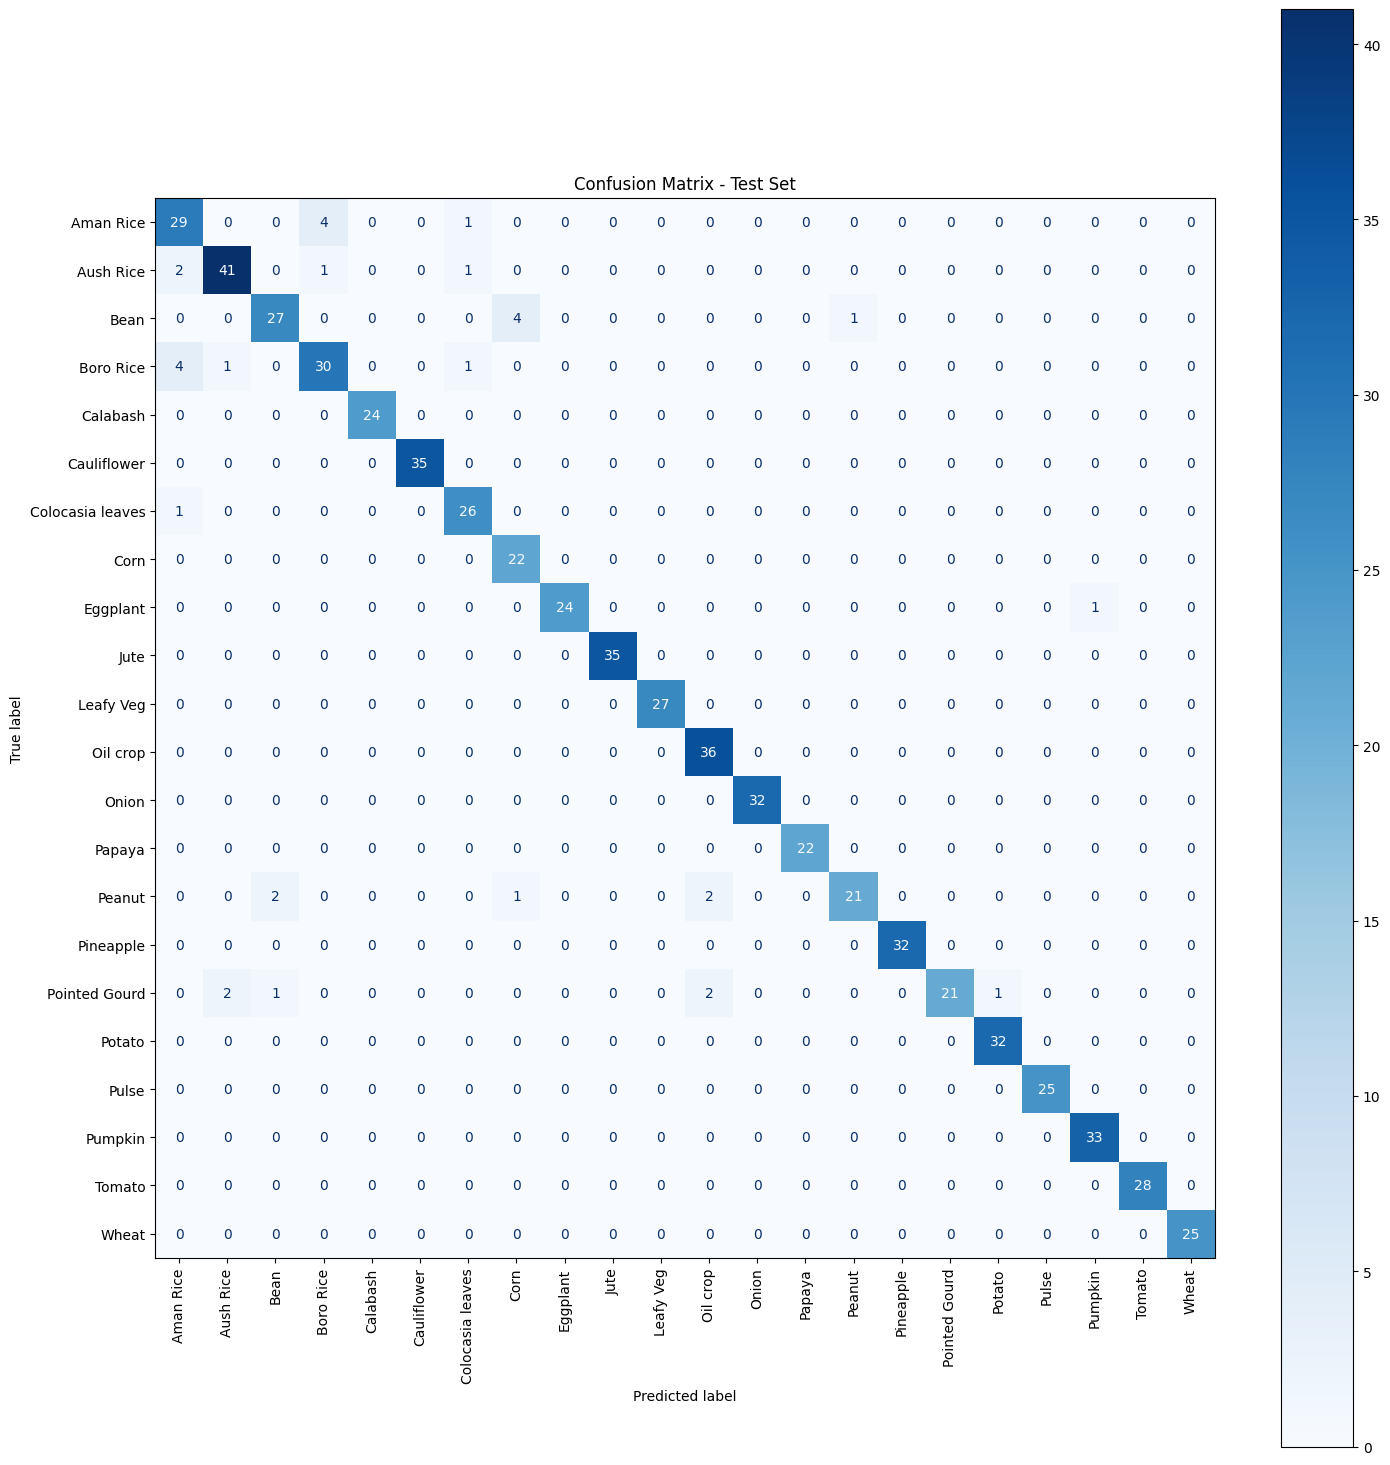


Confusion Matrix plot has been displayed.
The diagonal from top-left to bottom-right shows correct predictions.
Off-diagonal values are misclassifications.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay , classification_report
from sklearn.datasets import make_classification

print("Making predictions on the test set...")
y_pred = best_model.predict(X_test)


# --- Generate and Display Confusion Matrix ---
print("Generating confusion matrix...")

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(15, 15))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    ax=ax,
    xticks_rotation='vertical',
    cmap='Blues'
)

plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

print("\nConfusion Matrix plot has been displayed.")
print("The diagonal from top-left to bottom-right shows correct predictions.")
print("Off-diagonal values are misclassifications.")


In [76]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        34
           1       0.93      0.91      0.92        45
           2       0.90      0.84      0.87        32
           3       0.86      0.83      0.85        36
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        35
           6       0.90      0.96      0.93        27
           7       0.81      1.00      0.90        22
           8       1.00      0.96      0.98        25
           9       1.00      1.00      1.00        35
          10       1.00      1.00      1.00        27
          11       0.90      1.00      0.95        36
          12       1.00      1.00      1.00        32
          13       1.00      1.00      1.00        22
          14       0.95      0.81      0.88        26
          15       1.00      1.00      1.00        32
          16       1.00      0.78      0.88        27
          17       0.97    